In [11]:
import os
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colormaps
import numpy as np
import pandas as pd

plt.rcParams['font.family'] = 'Times New Roman'
matplotlib.style.use('tableau-colorblind10') #seaborn-v0_8-whitegrid  tableau-colorblind10

In [2]:
len_cf = 101  # add 1 as CFs value starting from year_0
MYs = [2020, 2030, 2040, 2050] #, 2060, 2070]
ssps = ["119", "245", "585"]   #"126"
sp_col, my_col = [], []

In [3]:
ghggass = [ "CH4", "N2O"]  #CO2 

from collections import defaultdict
#  3-layer nested dict
cf_col_gas_allgas = defaultdict(lambda: defaultdict(dict))

for ghggas in ghggass: 
    cf_col_gas = []
    for sp in ssps:
        for MY in MYs:
            #print(f"read point GWP value for {ghggas} SSP {sp}, model year {MY}")
            filename = "agwp_dcf_gwp100_tstep1" + ghggas + "_ssp" + sp + "_fair_start2000MY" + str(MY) + ".xlsx"
            cf_file = os.path.join("../FaIR_dpCFs/output/metrics/", filename)

            cf_agwp_df = pd.read_excel(cf_file, sheet_name = "agwp_pointvalue" + ghggas+ "_" + str(MY) ) 
            cf_agwp_pointvalue = cf_agwp_df[ghggas].values
            cf_col_gas.append(cf_agwp_pointvalue)
    
            cf_col_gas_allgas[ghggas][f'ssp{sp}'][str(MY)] = cf_agwp_pointvalue

In [4]:
cf_col_gas_allgas['CH4']['ssp119']['2030']

array([0.00000000e+00, 2.13553272e-13, 4.09563118e-13, 5.89664257e-13,
       7.55368505e-13, 9.07490100e-13, 1.04772571e-12, 1.17669511e-12,
       1.29490251e-12, 1.40406396e-12, 1.50443808e-12, 1.59671432e-12,
       1.68134467e-12, 1.75904340e-12, 1.83051030e-12, 1.89617833e-12,
       1.95671272e-12, 2.01206303e-12, 2.06299473e-12, 2.11006069e-12,
       2.15269047e-12, 2.19180922e-12, 2.22770178e-12, 2.26062977e-12,
       2.29083340e-12, 2.31837502e-12, 2.34359012e-12, 2.36698427e-12,
       2.38842714e-12, 2.40807519e-12, 2.42607212e-12, 2.44266359e-12,
       2.45792697e-12, 2.47197963e-12, 2.48474842e-12, 2.49642087e-12,
       2.50708467e-12, 2.51681922e-12, 2.52557331e-12, 2.53343893e-12,
       2.54063236e-12, 2.54724815e-12, 2.55323966e-12, 2.55865502e-12,
       2.56353855e-12, 2.56793099e-12, 2.57186991e-12, 2.57538986e-12,
       2.57852268e-12, 2.58129770e-12, 2.58374194e-12, 2.58588031e-12,
       2.58773575e-12, 2.58932942e-12, 2.59068084e-12, 2.59180801e-12,
      

In [5]:
agwp_co2 =  pd.read_excel('AGWP_CO2_fixed.xlsx' )
agwp_co2_TH101 = agwp_co2.iloc[:101]
#agwp_co2_TH101

agwp_co2_vals = agwp_co2_TH101['AGWP_CO2_fixed'].values[1:]  # shape (100,)
agwp_co2_vals.shape

(100,)

### calculate dpGWP[CH4/N2O] but with fixed AGWP[CO2] (not changing per MY/SSP)

In [6]:

# Output dictionary to store GWP values
gwp_results = {}

for ghg in cf_col_gas_allgas:
    gwp_results[ghg] = {}
    for ssp in cf_col_gas_allgas[ghg]:
        gwp_results[ghg][ssp] = {}
        
        for MY in cf_col_gas_allgas[ghg][ssp]:
            arr = cf_col_gas_allgas[ghg][ssp][MY]

            arr_trimmed = arr[1:101]  # drops 0th element, keeps next 100

            # get GWP values (elementwise divide by CO2 AGWP)
            gwp_array = arr_trimmed / agwp_co2_vals

            # Store result
            gwp_results[ghg][ssp][MY] = gwp_array

### dpGWP[CH4] now follows it's absolute metric trend where SSP119 have higher CFs than SSP585

In [7]:
gwp_results['CH4']['ssp119']['2030']

array([129.35260081, 127.95999432, 126.32654583, 124.50792185,
       122.47522915, 120.35396825, 118.12240596, 115.7773258 ,
       113.42810382, 111.04841122, 108.6574017 , 106.25936429,
       103.87718653, 101.5305452 ,  99.2231558 ,  96.97138255,
        94.7561067 ,  92.59960659,  90.51196245,  88.45614113,
        86.4606495 ,  84.52577398,  82.65130865,  80.83665451,
        79.07550608,  77.37162268,  75.73393993,  74.15076743,
        72.62057144,  71.14174969,  69.71590264,  68.33989453,
        67.01208789,  65.72605285,  64.48277861,  63.28071242,
        62.11829951,  60.99102411,  59.89818813,  58.8420771 ,
        57.8220743 ,  56.83451164,  55.87810747,  54.95162778,
        54.05388588,  53.18374173,  52.34010108,  51.5219144 ,
        50.72817571,  49.95792123,  49.21022809,  48.48421288,
        47.77903023,  47.09387139,  46.42796277,  45.78056451,
        45.15096914,  44.53850012,  43.94251062,  43.36238212,
        42.7975232 ,  42.24736836,  41.71137676,  41.19

In [8]:
gwp_results['CH4']['ssp585']['2030']

array([121.56687757, 119.79906722, 117.83033993, 115.69814056,
       113.48566536, 111.11904443, 108.73027204, 106.30077129,
       103.8369204 , 101.36043773,  98.92745382,  96.49659194,
        94.09428999,  91.71878045,  89.41514252,  87.17432071,
        85.01099853,  82.91183022,  80.87812384,  78.91039815,
        77.00853682,  75.16897628,  73.38674533,  71.66835134,
        70.01267793,  68.42390516,  66.89297865,  65.41797238,
        63.99691599,  62.62782134,  61.31113003,  60.0374014 ,
        58.80373394,  57.61674244,  56.47339799,  55.37118837,
        54.30833885,  53.28474037,  52.30452449,  51.34961504,
        50.42482532,  49.53176942,  48.6690442 ,  47.83531068,
        47.03126888,  46.25361945,  45.50114592,  44.77275896,
        44.06742113,  43.38414472,  42.72198953,  42.0800607 ,
        41.45750667,  40.85351706,  40.26732074,  39.69818386,
        39.14540806,  38.60832866,  38.08631299,  37.57875875,
        37.08509248,  36.60476804,  36.13726526,  35.68

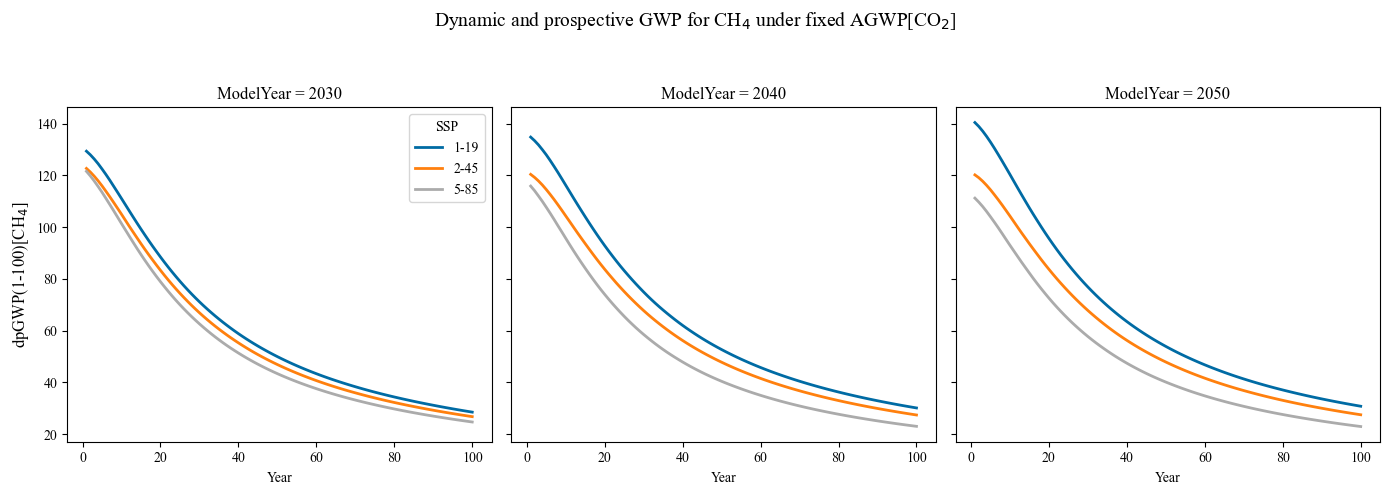

In [12]:

fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)
years = range(1, 101)

model_years = ['2030', '2040', '2050']
ssp_labels = {'ssp119': '1-19', 'ssp245': '2-45', 'ssp585': '5-85'}

for i, my in enumerate(model_years):
    ax = axes[i]

    # Plot each SSP line
    for ssp in ['ssp119', 'ssp245', 'ssp585']:
        gwp = gwp_results['CH4'][ssp][my]
        ax.plot(years, gwp, label=ssp_labels[ssp], linewidth=2)

    ax.set_title(f'ModelYear = {my}')
    ax.set_xlabel('Year')
    if i == 0:
        ax.set_ylabel(r'dpGWP(1-100)[CH$_4$]', fontsize = 12 )
        ax.legend(title='SSP')  # Only add legend to the first subplot
        
    #ax.grid(True)
 
fig.suptitle(r'Dynamic and prospective GWP for CH$_4$ under fixed AGWP[CO$_2$]', fontsize=14)
handles, labels = axes[0].get_legend_handles_labels()

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

### dpGWP[N2O] doesn't really change a lot, per future MY/SSP, caz now AGWP[CO2] fixed, also the N2O itself doesn't change per MY/SSP as CH4 does 

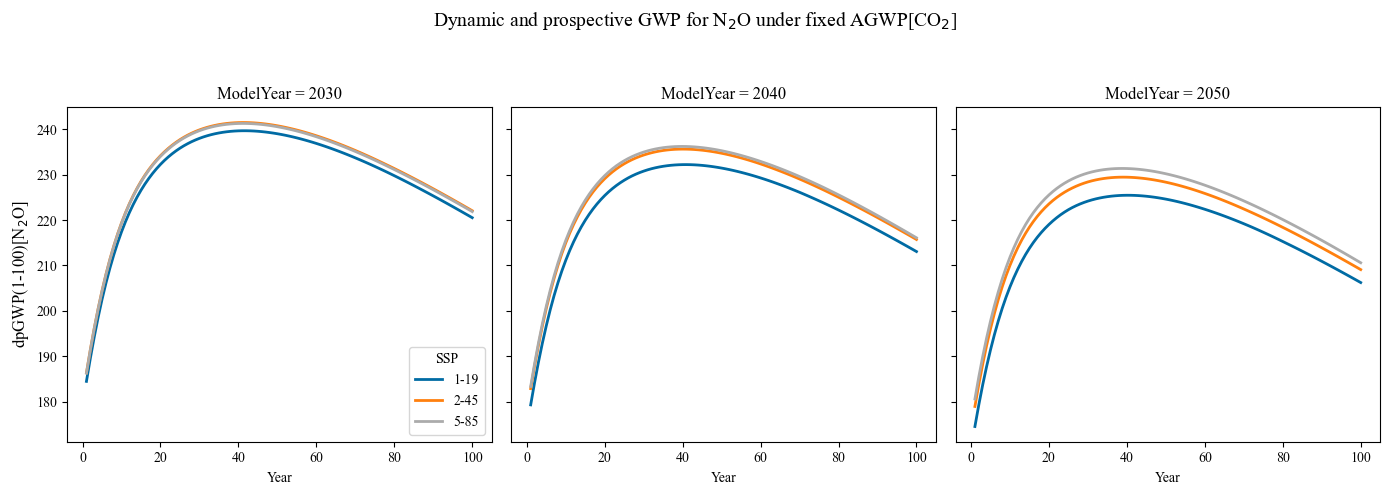

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)
years = range(1, 101)

model_years = ['2030', '2040', '2050']
ssp_labels = {'ssp119': '1-19', 'ssp245': '2-45', 'ssp585': '5-85'}

for i, my in enumerate(model_years):
    ax = axes[i]

    # Plot each SSP line
    for ssp in ['ssp119', 'ssp245', 'ssp585']:
        gwp = gwp_results['N2O'][ssp][my]
        ax.plot(years, gwp, label=ssp_labels[ssp], linewidth=2)

    ax.set_title(f'ModelYear = {my}')
    ax.set_xlabel('Year')
    if i == 0:
        ax.set_ylabel(r'dpGWP(1-100)[N$_2$O]', fontsize = 12 )
        ax.legend(title='SSP')  # Only add legend to the first subplot
        
    #ax.grid(True)
 
fig.suptitle(r'Dynamic and prospective GWP for N$_2$O under fixed AGWP[CO$_2$]', fontsize=14)
handles, labels = axes[0].get_legend_handles_labels()

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

### convert dict to DF then to .nc

In [15]:
records = []

for ssp in gwp_results['CH4'].keys():
    for my in gwp_results['CH4'][ssp].keys():
        # Add Year 0 first
        records.append((ssp, my, 0, 1.0, 0.0, 0.0))  # CO2 GWP = 1.0 by default

        for year in range(1, 101):
            co2 = 1.0  # Static CO2 GWP
            ch4 = gwp_results['CH4'][ssp][my][year - 1]
            n2o = gwp_results['N2O'][ssp][my][year - 1]
            records.append((ssp, my, year, co2, ch4, n2o))

# Step 2: Create DataFrame
df = pd.DataFrame(records, columns=["SSP", "ModelYear", "Year", "CO2_GWP", "CH4_GWP", "N2O_GWP"])
df = df.set_index(["SSP", "ModelYear", "Year"])
df

CO2_GWP     CH4_GWP     N2O_GWP
SSP    ModelYear Year                                 
ssp119 2020      0         1.0    0.000000    0.000000
                 1         1.0  128.379377  188.574448
                 2         1.0  126.706735  193.793514
                 3         1.0  124.741411  198.625933
                 4         1.0  122.601680  203.072652
...                        ...         ...         ...
ssp585 2050      96        1.0   23.745009  212.594467
                 97        1.0   23.541239  212.096970
                 98        1.0   23.341118  211.597165
                 99        1.0   23.145053  211.095159
                 100       1.0   22.952932  210.591056

[1212 rows x 3 columns]

In [16]:
#Deleting rows with YEAR_index value 0
cf_df_filtered = df[~df.index.get_level_values("Year").isin([0])]
#cf_df_filtered

print(len(df), len(cf_df_filtered))

1212 1200


In [17]:
cf_xr = df.to_xarray() 
cf_xr2 = cf_df_filtered.to_xarray() 

In [18]:
cf_xr.to_netcdf('output_dpGWP_fixedCO2/CF_GWP0_100_perSSP_MY_majorghgs.nc')
cf_xr2.to_netcdf('output_dpGWP_fixedCO2/CF_GWP1_100_perSSP_MY_majorghgs.nc')

In [19]:
cf_xr2

<xarray.Dataset>
Dimensions:    (SSP: 3, ModelYear: 4, Year: 100)
Coordinates:
  * SSP        (SSP) object 'ssp119' 'ssp245' 'ssp585'
  * ModelYear  (ModelYear) object '2020' '2030' '2040' '2050'
  * Year       (Year) int64 1 2 3 4 5 6 7 8 9 10 ... 92 93 94 95 96 97 98 99 100
Data variables:
    CO2_GWP    (SSP, ModelYear, Year) float64 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0
    CH4_GWP    (SSP, ModelYear, Year) float64 128.4 126.7 124.7 ... 23.15 22.95
    N2O_GWP    (SSP, ModelYear, Year) float64 188.6 193.8 198.6 ... 211.1 210.6

In [20]:
df.to_excel("GWP_output_fixed_AGWPCO2.xlsx", index = True)